In [1]:
from kika.endf.read_endf import read_endf
from kika.utils import configure_endf_debug_logging
import logging
from kika.cov.multigroup.mg_mf34_covmat import MGMF34CovMat
from kika.cov.multigroup.MF34_to_MG import MF34_to_MG
from kika.energy_grids import SCALE56
from kika.plotting import PlotBuilder
import pandas as pd
import numpy as np

# === DEBUG LOGGING SETUP ===
modules = [
    'kika.endf.parsers.parse_mf34',
    ]
configure_endf_debug_logging(enable=False, level=logging.DEBUG, modules=modules)

<RootLogger root (WARNING)>

In [2]:
#jendl_Fe56 = '/share_snc/snc/JuanMonleon/n-26056_jendl.txt'
#jendl_endf = read_endf(jendl_Fe56)

In [3]:
#jeff_Fe56 = '/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt'
jeff_Fe56 =  r"c:\Users\Usuario\BaradDur\Dev\kika\files\endf\26-Fe-56g_mf34.txt"
jeff_Pu239 = r"c:\Users\Usuario\BaradDur\Dev\kika\files\endf\Pu239_endfb8.1_n.endf"
jeff_endf_Pu239 = read_endf(jeff_Pu239, mf_numbers=[4,34])
jeff_endf_Fe56 = read_endf(jeff_Fe56, mf_numbers=[4,34])
cov_Pu239 = jeff_endf_Pu239.mf[34].to_ang_covmat()
cov_Fe56 = jeff_endf_Fe56.mf[34].to_ang_covmat()

In [4]:
_, unc_Pu239 = cov_Pu239.to_plot_data(nuclide='Pu239', mt=2, order=1)
_, unc_Fe56 = cov_Fe56.to_plot_data(nuclide='Fe56', mt=2, order=1)

In [5]:
unc_Pu239

LegendreUncertaintyPlotData(x=array([1.0e-05, 1.0e+03, 2.0e+03, 5.0e+03, 8.0e+03, 1.0e+04, 2.0e+04,
       3.0e+04, 4.0e+04, 6.0e+04, 8.0e+04, 1.0e+05, 2.0e+05, 3.0e+05,
       4.0e+05, 6.0e+05, 8.0e+05, 1.0e+06, 1.2e+06, 1.5e+06, 2.0e+06,
       2.5e+06, 3.0e+06, 3.5e+06, 4.0e+06, 5.0e+06, 6.0e+06, 7.0e+06,
       8.0e+06, 9.0e+06, 1.0e+07, 1.2e+07, 1.4e+07, 1.5e+07, 1.6e+07,
       1.8e+07, 2.0e+07]), y=array([ 0.   , 16.5  , 14.7  , 12.3  , 11.1  , 10.2  ,  8.51 ,  7.72 ,
        7.13 ,  6.25 ,  5.5  ,  4.86 ,  2.86 ,  2.38 ,  2.18 ,  2.25 ,
        2.18 ,  2.05 ,  2.16 ,  2.34 ,  2.19 ,  1.68 ,  1.23 ,  0.932,
        0.773,  0.596,  0.76 ,  1.18 ,  1.5  ,  1.62 ,  1.57 ,  1.27 ,
        0.973,  0.824,  0.69 ,  0.476,  0.476]), label='Pu239 MT=2 L=1 (σ %)', color=None, linestyle='-', linewidth=None, marker=None, markersize=None, alpha=None, plot_type='step', drawstyle=None, metadata={'order': 1, 'isotope': 'Pu239', 'mt': 2, 'uncertainty_type': 'relative'}, order=1, isotope='Pu239',

In [6]:
unc_Fe56

LegendreUncertaintyPlotData(x=array([1.00e-05, 5.00e+04, 1.50e+05, 2.50e+05, 3.50e+05, 4.50e+05,
       5.50e+05, 6.50e+05, 7.50e+05, 8.50e+05, 1.00e+06, 1.20e+06,
       1.40e+06, 1.60e+06, 1.80e+06, 2.00e+06, 2.20e+06, 2.40e+06,
       2.60e+06, 2.80e+06, 3.00e+06, 3.50e+06, 4.00e+06, 4.50e+06,
       5.00e+06, 5.50e+06, 6.00e+06, 7.00e+06, 8.00e+06, 9.00e+06,
       1.00e+07, 1.10e+07, 1.20e+07, 1.30e+07, 1.35e+07, 1.40e+07,
       1.45e+07, 1.50e+07, 1.60e+07, 1.70e+07, 1.80e+07, 1.90e+07,
       2.00e+07]), y=array([30.11976096, 42.47352116, 20.63976744, 21.40327078, 12.86468033,
       12.96533841, 18.02498266, 55.42562584, 28.54645337,  4.5177428 ,
        5.36003731, 12.0124935 ,  4.64758002,  3.57910603,  4.00874045,
        2.26141549,  2.63628527,  2.4989998 ,  1.57194147,  1.54402073,
        1.2561847 ,  1.21284789,  3.00000017,  3.00000017,  3.00000017,
        3.00000017,  3.00000017,  3.00000017,  3.00000017,  3.00000017,
        3.00000017,  3.00000017,  3.00000017,  3

✓ Single MT uncertainties plot created


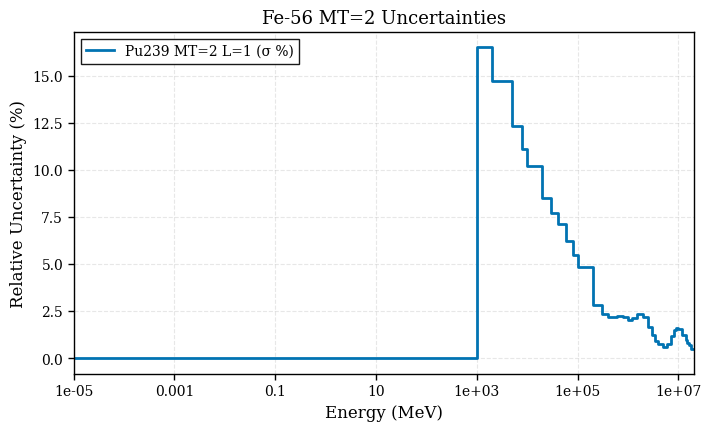

: 

In [ ]:
# Build plot using PlotBuilder
builder = PlotBuilder(style='light', figsize=(10, 6))
builder.add_data(unc_Pu239)  # Plot uncertainties
builder.set_labels(x_label='Energy (MeV)', y_label='Relative Uncertainty (%)', title='Fe-56 MT=2 Uncertainties')
builder.set_scales(log_x=True)
#builder.set_limits(x_lim=(1e-5, 20))
fig = builder.build()

print("✓ Single MT uncertainties plot created")